# Global Water Watch reservoir timeseries — worked example

This notebook opens the archive, explains how it is laid out, and extracts and
plots the timeseries for one reservoir.

The archive holds satellite-derived **surface water area** for 71,208 lakes and
reservoirs worldwide, 1985–2026, preserved from the
[Global Water Watch](https://www.globalwaterwatch.earth/) platform before it was
decommissioned. See `README.md` for the full description, citation and licence.

Requirements: `pip install xarray netCDF4 pandas matplotlib`

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

NC_PATH = "gww_reservoir_timeseries.nc"

ds = xr.open_dataset(NC_PATH)
ds

<xarray.Dataset> Size: 1GB
Dimensions:                      (geometry_bytes: 315120630, reservoir: 71208,
                                  time: 500, obs_surface_water_area: 44808972)
Coordinates:
  * reservoir                    (reservoir) int64 570kB 1 3 4 ... 92438 92471
  * time                         (time) datetime64[ns] 4kB 1985-01-01 ... 202...
Dimensions without coordinates: geometry_bytes, obs_surface_water_area
Data variables: (12/18)
    geometry_utf8                (geometry_bytes) uint8 315MB ...
    geometry_row_size            (reservoir) int64 570kB ...
    longitude                    (reservoir) float64 570kB ...
    latitude                     (reservoir) float64 570kB ...
    bbox_west                    (reservoir) float64 570kB ...
    bbox_east                    (reservoir) float64 570kB ...
    ...                           ...
    grand_id                     (reservoir) <U4 1MB ...
    download_ok                  (reservoir) int8 71kB ...
    surface_water_area_row_size  (reservoir) int32 285kB ...
    surface_water_area_monthly   (reservoir, time) float32 142MB ...
    surface_water_area           (obs_surface_water_area) float32 179MB ...
    surface_water_area_time      (obs_surface_water_area) datetime64[ns] 358MB ...
Attributes:
    title:              Global Water Watch reservoir timeseries archive
    summary:            Reservoir surface water timeseries downloaded from th...
    source:             https://api.globalwaterwatch.earth
    references:         https://www.globalwaterwatch.earth/
    featureType:        timeSeries
    Conventions:        CF-1.10
    history:            2026-09-07T11:10:29.087224+00:00 merged 214 chunks by...
    n_reservoirs:       71208
    monthly_variables:  surface_water_area_monthly
    ragged_variables:   surface_water_area

## How the archive is laid out

There are two kinds of timeseries in the file, stored differently.

**1. Monthly aggregates — a dense 2-D grid.**
Every reservoir shares the same monthly calendar, so `surface_water_area_monthly`
is simply `(reservoir, time)`. Months with no observation are `NaN`. You index it
the obvious way: `ds["surface_water_area_monthly"].sel(reservoir=123)`.

**2. Raw satellite observations — a ragged array.**
Each reservoir is observed at its own overpass times, shared with no other
reservoir. On a common time axis they would form a grid that is over 99.9%
missing, so instead every reservoir's observations are laid end to end along one
flat dimension (the CF *contiguous ragged array* representation):

```
reservoir index :  [   0   ][      1      ][  2  ] ...
row_size        :     25          371        238
                      ↓            ↓           ↓
obs_...         :  |---25---|-----371-----|-238-|     one flat dimension
surface_water_area_time : timestamp of every element
surface_water_area      : value of every element
```

`surface_water_area_row_size(reservoir)` gives each reservoir's block length, in
reservoir order. The cumulative sum gives the slice boundaries — that is all the
helper further down does.

**Everything else** (`longitude`, `latitude`, `bbox_*`, `name`, `grand_id`,
`geometry_row_size`, `download_ok`, …) is one value per reservoir.

Areas are in **m²** throughout.

In [2]:
print("dimensions:", dict(ds.sizes))
print()
print("monthly variables:", ds.attrs["monthly_variables"])
print("ragged variables :", ds.attrs["ragged_variables"])
print()
print(ds.attrs["history"])

dimensions: {'geometry_bytes': 315120630, 'reservoir': 71208, 'time': 500, 'obs_surface_water_area': 44808972}

monthly variables: surface_water_area_monthly
ragged variables : surface_water_area

2026-09-07T11:10:29.087224+00:00 merged 214 chunks by download_gww.py


## What is in the file?

Per-reservoir metadata only — this stays fast even across all 71k reservoirs,
because no timeseries data is touched.

In [3]:
overview = pd.DataFrame({
    "reservoir": ds["reservoir"].values,
    "name": [str(n) for n in ds["name"].values],
    "lon": ds["longitude"].values.round(4),
    "lat": ds["latitude"].values.round(4),
    "source": [str(s) for s in ds["source_name"].values],
    "n_raw_obs": ds["surface_water_area_row_size"].values,
    "ok": ds["download_ok"].values,
}).set_index("reservoir")

print(f"{len(overview):,} reservoirs")
print(f"{(overview['ok'] == 0).sum():,} with download_ok = 0 (no data archived for them)")
overview.head(20)

71,208 reservoirs
0 with download_ok = 0 (no data archived for them)


,name,lon,lat,source,n_raw_obs,ok
reservoir,,,,,,
1,,-84.0946,30.8625,osm_way,25,1
3,,116.0158,-33.9785,osm_way,371,1
4,,143.3099,-37.5180,osm_way,238,1
5,,57.0989,29.4671,osm_way,203,1
6,,5.8756,51.9344,osm_way,397,1
7,,-117.3488,43.7176,osm_way,49,1
8,,-5.7843,39.8859,osm_way,573,1
9,,90.2507,28.6521,osm_way,92,1
10,Lago della Vacca,10.4392,45.9549,osm_way,67,1


## Pick a reservoir

Change `RESERVOIR_ID` to any id from the table above. The default picks whichever
reservoir has the most observations, so the plots have something to show.

In [4]:
RESERVOIR_ID = int(overview["n_raw_obs"].idxmax())   # <- edit this

meta = overview.loc[RESERVOIR_ID]
print(f"reservoir {RESERVOIR_ID}: {meta['name'] or '(unnamed)'}")
print(f"  location : {meta['lat']:.4f} N, {meta['lon']:.4f} E   (source: {meta['source']})")
print(f"  raw obs  : {meta['n_raw_obs']:,}")

reservoir 72195: (unnamed)
  location : 34.2865 N, -114.2297 E   (source: HydroLAKES)
  raw obs  : 2,737


### The monthly series — a straightforward selection

In [5]:
monthly = (
    ds["surface_water_area_monthly"]
    .sel(reservoir=RESERVOIR_ID)
    .to_series()
    .dropna()                    # drop months outside this reservoir's record
)

print(f"{len(monthly)} months, {monthly.index[0]:%Y-%m} to {monthly.index[-1]:%Y-%m}")
monthly.head()

500 months, 1985-01 to 2026-08


time
1985-01-01    1518170.625
1985-02-01    1518170.625
1985-03-01    1518170.625
1985-04-01    1518170.625
1985-05-01    1518170.625
Name: surface_water_area_monthly, dtype: float32

### The raw series — unpack the ragged array

`row_size` gives the block lengths; the cumulative sum gives the offsets.

Note the indexing order: `ds[var][sl].values`, **not** `ds[var].values[sl]`.
The first reads just this reservoir's block from disk; the second would load
every observation in the file (~500 MB) to return one reservoir's data.

In [6]:
def ragged_slice(ds, variable, reservoir_id):
    """(times, values) for one reservoir from a contiguous ragged array."""
    ids = ds["reservoir"].values
    hits = np.flatnonzero(ids == int(reservoir_id))
    if hits.size == 0:
        raise KeyError(f"reservoir {reservoir_id} is not in this file")
    i = int(hits[0])

    row_size = ds[f"{variable}_row_size"].values
    start = int(row_size[:i].sum())
    sl = slice(start, start + int(row_size[i]))

    return ds[f"{variable}_time"][sl].values, ds[variable][sl].values


times, values = ragged_slice(ds, "surface_water_area", RESERVOIR_ID)
raw = pd.Series(values, index=pd.DatetimeIndex(times), name="surface_water_area")

print(f"{len(raw)} observations, {raw.index[0]:%Y-%m-%d} to {raw.index[-1]:%Y-%m-%d}")
raw.head()

2737 observations, 1985-01-03 to 2026-08-29


1985-01-03 17:40:00    1537021.000
1985-01-19 17:40:00    1523306.875
1985-05-11 17:39:00    1518170.625
1985-08-15 17:39:00    1494433.000
1985-09-16 17:39:00    1492949.750
Name: surface_water_area, dtype: float32

## Plot the timeseries

Individual satellite observations (dots) against the monthly aggregate (line).

Areas are stored in m². Reservoirs in this archive range from farm ponds of a few
hundred m² to major lakes, so the cell below picks a readable unit rather than
assuming km².

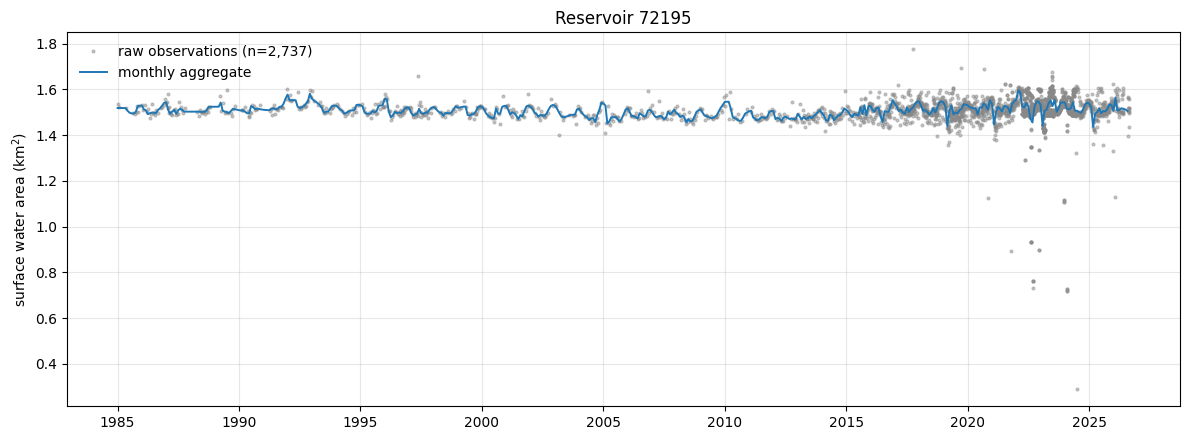

In [7]:
def area_unit(values_m2):
    """Pick m2 / ha / km2 based on the magnitude of the data."""
    typical = np.nanmedian(np.abs(values_m2))
    if typical >= 1e6:
        return 1e6, "surface water area (km$^2$)"
    if typical >= 1e4:
        return 1e4, "surface water area (ha)"
    return 1.0, "surface water area (m$^2$)"


scale, label = area_unit(monthly.values)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(raw.index, raw.values / scale, ".", ms=4, alpha=0.45, color="#888888",
        label=f"raw observations (n={len(raw):,})")
ax.plot(monthly.index, monthly.values / scale, "-", lw=1.4, color="#1f77b4",
        label="monthly aggregate")

title = f"Reservoir {RESERVOIR_ID}"
if meta["name"]:
    title += f" — {meta['name']}"
ax.set_title(title)
ax.set_ylabel(label)
ax.grid(alpha=0.3)
ax.legend(frameon=False)
fig.tight_layout()

Observation density increases markedly from around 2015, when Sentinel-2 joined
Landsat. Apparent changes in variability across that boundary may reflect
sampling rather than the reservoir itself.

## Plot the outline

Outlines are archived as GeoJSON, stored as ragged UTF-8 bytes (see the helper below).

These outlines come from OpenStreetMap and HydroLAKES; OpenStreetMap data is
ODbL-licensed and requires attribution to "© OpenStreetMap contributors" if you
redistribute it. `source_name` says which dataset each reservoir came from.

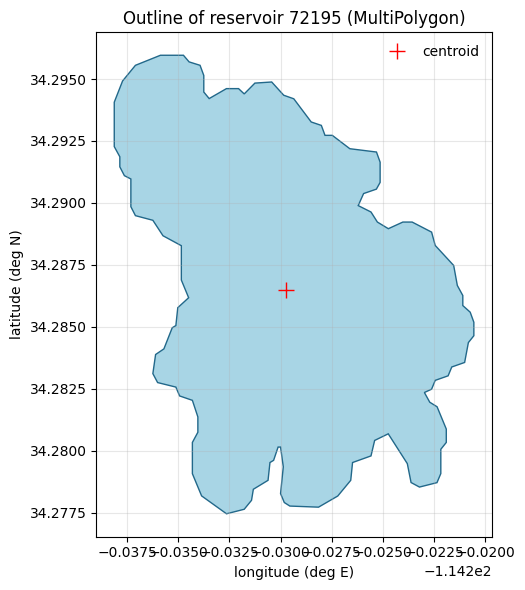

In [8]:
def reservoir_geometry(ds, reservoir_id):
    """The GeoJSON outline of one reservoir, as a dict.

    Outlines are stored the same ragged way as the observations: UTF-8 encoded
    and concatenated along `geometry_bytes`, with `geometry_row_size` giving
    each reservoir's byte count. They range from 271 bytes to 935 kB, and one
    string per reservoir would make xarray widen the variable to a fixed
    935,507 characters across all 71,208 rows -- a 248 GiB allocation.
    """
    ids = ds["reservoir"].values
    hits = np.flatnonzero(ids == int(reservoir_id))
    if hits.size == 0:
        raise KeyError(f"reservoir {reservoir_id} is not in this file")
    i = int(hits[0])

    row_size = ds["geometry_row_size"].values
    start = int(row_size[:i].sum())
    n = int(row_size[i])
    if n == 0:
        return None
    return json.loads(ds["geometry_utf8"][start:start + n].values.tobytes().decode("utf-8"))


geom = reservoir_geometry(ds, RESERVOIR_ID)
i = int(np.flatnonzero(ds["reservoir"].values == RESERVOIR_ID)[0])   # for the centroid

polygons = geom["coordinates"] if geom["type"] == "MultiPolygon" else [geom["coordinates"]]

fig, ax = plt.subplots(figsize=(6, 6))
for poly in polygons:
    for ring_no, ring in enumerate(poly):
        xy = np.asarray(ring)
        # ring 0 is the exterior; any further rings are holes
        ax.fill(xy[:, 0], xy[:, 1],
                facecolor="#a8d5e5" if ring_no == 0 else "white",
                edgecolor="#22688a", lw=1.0, zorder=ring_no)

ax.plot(ds["longitude"].values[i], ds["latitude"].values[i], "r+", ms=12, label="centroid")
ax.set_aspect(1 / np.cos(np.deg2rad(float(ds["latitude"].values[i]))))
ax.set_xlabel("longitude (deg E)")
ax.set_ylabel("latitude (deg N)")
ax.set_title(f"Outline of reservoir {RESERVOIR_ID} ({geom['type']})")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()

## Seasonality

Mean area by calendar month — a quick check that the series behaves like a
reservoir.

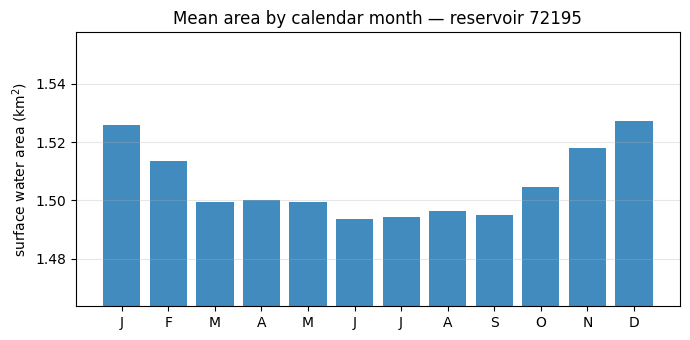

In [9]:
clim = monthly.groupby(monthly.index.month).mean() / scale

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(clim.index, clim.values, color="#1f77b4", alpha=0.85)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
ax.set_ylabel(label)
ax.set_title(f"Mean area by calendar month — reservoir {RESERVOIR_ID}")
ax.set_ylim(clim.min() * 0.98, clim.max() * 1.02)
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()

## Export

Both series in one table, for use outside xarray.

In [10]:
both = pd.DataFrame({"monthly": monthly}).join(pd.DataFrame({"raw": raw}), how="outer")
both.index.name = "time"

both.to_csv(f"reservoir_{RESERVOIR_ID}.csv")
print(f"wrote reservoir_{RESERVOIR_ID}.csv  ({len(both)} rows)")
both.head()

wrote reservoir_72195.csv  (3230 rows)


,monthly,raw
time,,
1985-01-01 00:00:00,1518170.625,NaN
1985-01-03 17:40:00,NaN,1537021.000
1985-01-19 17:40:00,NaN,1523306.875
1985-02-01 00:00:00,1518170.625,NaN
1985-03-01 00:00:00,1518170.625,NaN


## Many reservoirs at once

The dense monthly grid is built for this. Capped at `MAX_LINES` — the archive
holds ~71k reservoirs, and plotting them all would neither render nor read.

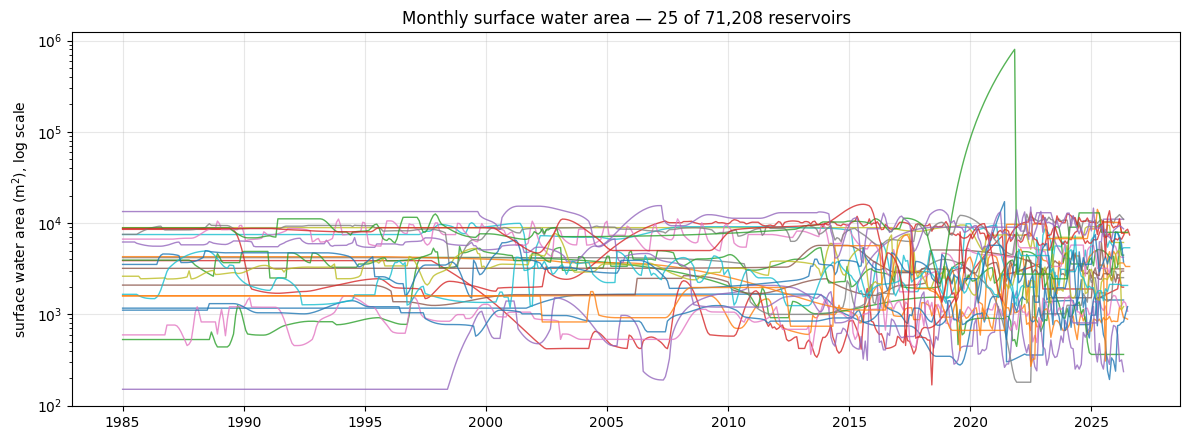

In [11]:
MAX_LINES = 25

ids = ds["reservoir"].values[:MAX_LINES]
block = ds["surface_water_area_monthly"].sel(reservoir=ids)

frame = block.to_pandas().T          # rows = time, columns = reservoir id
scale_all, label_all = area_unit(block.values)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(frame.index, frame.values / scale_all, lw=1, alpha=0.8)
ax.set_yscale("log")
ax.set_ylabel(label_all + ", log scale")
ax.set_title(f"Monthly surface water area — {len(ids)} of {ds.sizes['reservoir']:,} reservoirs")
ax.grid(alpha=0.3)
fig.tight_layout()

## Selecting reservoirs by location

In [12]:
west, east, south, north = 4.0, 8.0, 50.0, 54.0      # the Netherlands, roughly

inside = (
    (ds["longitude"] >= west) & (ds["longitude"] <= east)
    & (ds["latitude"] >= south) & (ds["latitude"] <= north)
)
selected = ds["reservoir"].values[inside.values]

print(f"{len(selected):,} reservoirs in the box")
print(selected[:20])

104 reservoirs in the box
[    6   129   210  1343  1835 31756  4811  4906  5056  6139  7503  9732
 10822 11373 11599 34831  3033 15316 47319 16892]


## Before you draw conclusions

- **Check `download_ok`.** A reservoir with `download_ok = 0` has no timeseries
  here because the archiving request was abandoned — not because the reservoir
  had no data. Treat it as missing, not as empty.
- **Observation density varies over time** (Landsat only before ~2015, Landsat +
  Sentinel-2 after).
- **Series end on different dates.** Each reservoir's record ends at its last
  usable scene, and the final month may aggregate fewer observations than usual.
- **Cloud, ice and shadow** affect water detection; individual observations can be
  outliers, and the monthly aggregate is more robust but not immune.
- **This is area, not storage.** Converting to volume needs an area–volume
  relationship, which is not part of this archive.

See `README.md` for the full caveats, citation and licence.

In [13]:
ds.close()